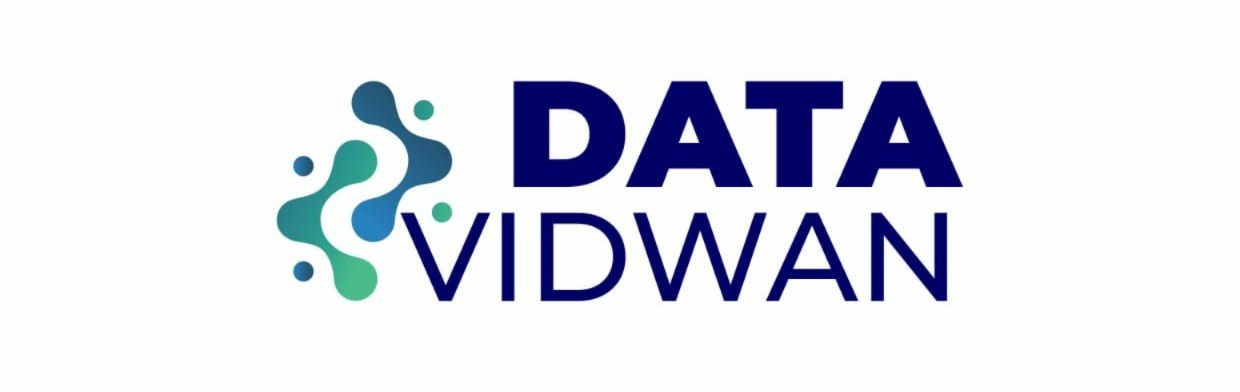

# **1. What are Outliers?**

Outliers are data points that are very different or far away from other values in the dataset.

For example:
- If most passengers on the Titanic paid between ₹10–₹100 for their ticket,
but one person paid ₹500, that ₹500 is an outlier.

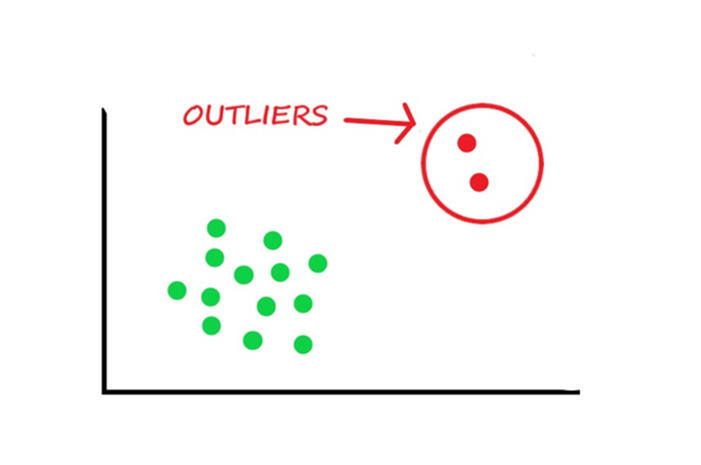

**Why do Outliers Happen?**

Outliers can appear due to:
- Data entry errors (someone typed 500 instead of 50)
- Measurement mistakes
- Natural variation (some people genuinely earn or spend much more)

**Why are Outluers Important?**

Outliers can affect your analysis and machine learning models badly.

Example:
- If you calculate the average fare, that one ₹500 ticket will increase the mean unfairly.
- In graphs, they make the scale stretch and hide patterns in data.
- In ML models, they can distort predictions (especially in linear models).


**What can we do with Outliers?**

we can:
- Detect them (find where they are)
- Analyze them (check if they are valid or errors)
- Remove or Treat them (if needed)

# **How to Detect Outliers**

We'll use three simple methods:
1. Visualization (Boxplot)
2. IQR Method (Interquartile Range)
3. Z-Score Method

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
Uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [ ]:
import pandas as pd
df = pd.read_csv('titanic.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


We will focus on numeric columns for outlier detection:

In [ ]:
numeric_cols = ['Age', 'Fare']
df_num = df[numeric_cols].copy()
df_num.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


**1. Method 1 Visualization (Boxplot)**

Outliers often appear as points outside the whiskers of the box.

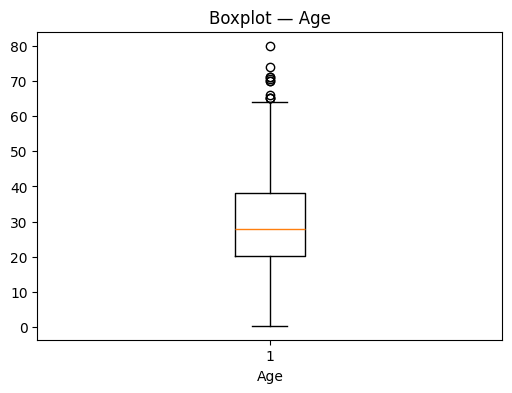

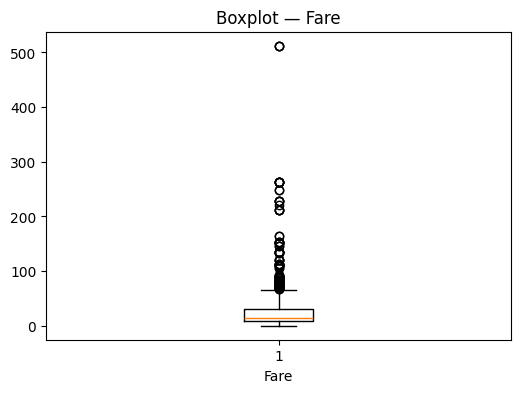

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_num[col].dropna())
    plt.title(f"Boxplot — {col}")
    plt.xlabel(col)
    plt.show()

**2. Method 2 - IQR Method**

IQR means Interquartile Range, which is the middle 50% of your data.
- IQR = Q3 − Q1
- Lower Limit = Q1 − 1.5 × IQR
- Upper Limit = Q3 + 1.5 × IQR

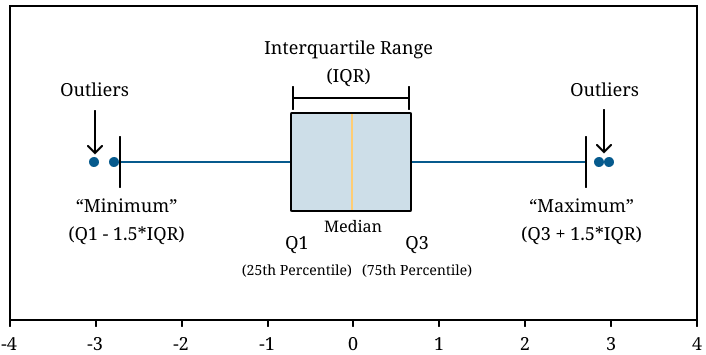

When we sort all values in a column (like Age):

- Q1 (25%) → value at 25% position
- Q3 (75%) → value at 75% position
- IQR = Q3 – Q1

So, IQR tells us how wide the middle part of our data is. Now we use this IQR to decide what is “too small” or “too large.”


**Finding the Normal Range**

We say:
- Anything below Q1 - 1.5 × IQR is too low → outlier
- Anything above Q3 + 1.5 × IQR is too high → outlier

These two formulas give us:
Lower Limit = Q1 - 1.5 x IQR
Upper Limit = Q3 + 1.5 x IQR

This becomes our normal range. Any data point outside this range is considered an outlier.

In [ ]:
for col in numeric_cols:
    s = df_num[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (df_num[col] < lower) | (df_num[col] > upper)

    print(f"=== {col} ===")
    print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"Lower={lower:.2f}, Upper={upper:.2f}")
    print(f"IQR Outliers: {outlier_mask.sum()}\n")

=== Age ===
Q1=20.12, Q3=38.00, IQR=17.88
Lower=-6.69, Upper=64.81
IQR Outliers: 11

=== Fare ===
Q1=7.91, Q3=31.00, IQR=23.09
Lower=-26.72, Upper=65.63
IQR Outliers: 116



**3. Method 3 - Z-Score Method**

How many standard deviations a point is from the mean.

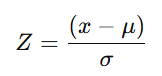

Where:

- x = value of the data point
- μ = mean of the column
- 𝜎 =  standard deviation of the column



**What it means:**

- If Z = 0 → the data point is exactly at the mean.
- If Z = +2 → the data point is 2 standard deviations above the mean.
- If Z = -3 → the data point is 3 standard deviations below the mean.

So, if any data point has |Z| > 3, it lies far away from the mean — that’s an outlier.

| Age |
| --- |
| 25  |
| 26  |
| 27  |
| 28  |
| 90  |

- Mean = 39.2
- Std Dev = 26.6

Now calculate Z-score for 90:

- Z=(90−39.2)/26.6=1.9

This is less than 3, so not a strong outlier.
But if we had 150,

- Z=(150−39.2)/26.6=4.17

|Z| > 3 → Outlier

**How to find Mean**

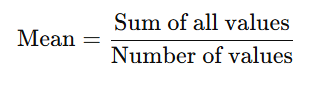

Example:

If we have Ages:
25, 26, 27, 28, 90

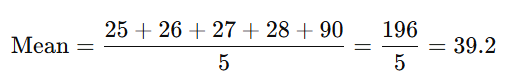

So, Mean = 39.2

**How to find Standard Deviation (σ)**

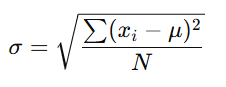

Where:

xi = each data point
μ = mean
N = number of values

| Age (xᵢ) | xᵢ - Mean         | (xᵢ - Mean)² |
| -------- | ----------------- | ------------ |
| 25       | 25 - 39.2 = -14.2 | 201.64       |
| 26       | -13.2             | 174.24       |
| 27       | -12.2             | 148.84       |
| 28       | -11.2             | 125.44       |
| 90       | 50.8              | 2580.64      |
| **Sum**  |                   | **3230.8**   |

Now:

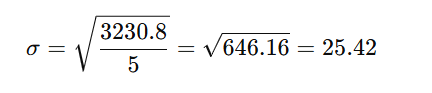
	​


In [ ]:
def zscore_series(s: pd.Series):
    s = s.dropna()
    return (s - s.mean()) / s.std(ddof=0) # ddof = Delta Degrees of Freedom If ddof = 0 → divide by N, If ddof = 1 → divide by N - 1

for col in numeric_cols:
    z = zscore_series(df_num[col])
    count = int((np.abs(z) > 3).sum())
    print(f"{col}: Z-score Outliers (>|3|) = {count}")

Age: Z-score Outliers (>|3|) = 2
Fare: Z-score Outliers (>|3|) = 20


**np.abs(z)**
- Takes absolute value
- So both +4 and −4 are treated the same

**> 3**
- Checks which values are more than 3 standard deviations away
- These are considered outliers

**.sum()**
- Counts how many values satisfy the condition

**Prints:**
- Column name
- Number of outliers found using Z-score

**Quick Summary Table (counts by method)**

In [ ]:
# IQR counts
iqr_counts = {}
for col in numeric_cols:
    s = df_num[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    iqr_counts[col] = int(((df_num[col] < lower) | (df_num[col] > upper)).sum())

# Z-score counts
z_counts = {}
for col in numeric_cols:
    z = zscore_series(df_num[col])
    z_counts[col] = int((np.abs(z) > 3).sum())

pd.DataFrame({'IQR_outliers': iqr_counts, 'Z_outliers': z_counts})

,IQR_outliers,Z_outliers
Age,11,2
Fare,116,20


IQR works better when:
- Data is skewed
- Distribution is not normal

Z-score works better when:
- Data is normally distributed

# **Handling Outliers**

**Why do we handle outliers?**

- When we find outliers, we have to decide what to do with them.
- Outliers are values that are too big or too small compared to other values.

If we don't handle them:
- Our average (mean) can become wrong.
- Our graphs can look stretched.
- Our machine learning models can give wrong results.

**Two Common Ways to Handle Outliers**

| Method       | What it does            | Example                                      |
| ------------ | ----------------------- | -------------------------------------------- |
| **Trimming** | Removes outlier rows    | Deletes those data points completely         |
| **Capping**  | Replaces outlier values | Keeps all rows, but fixes the extreme values |


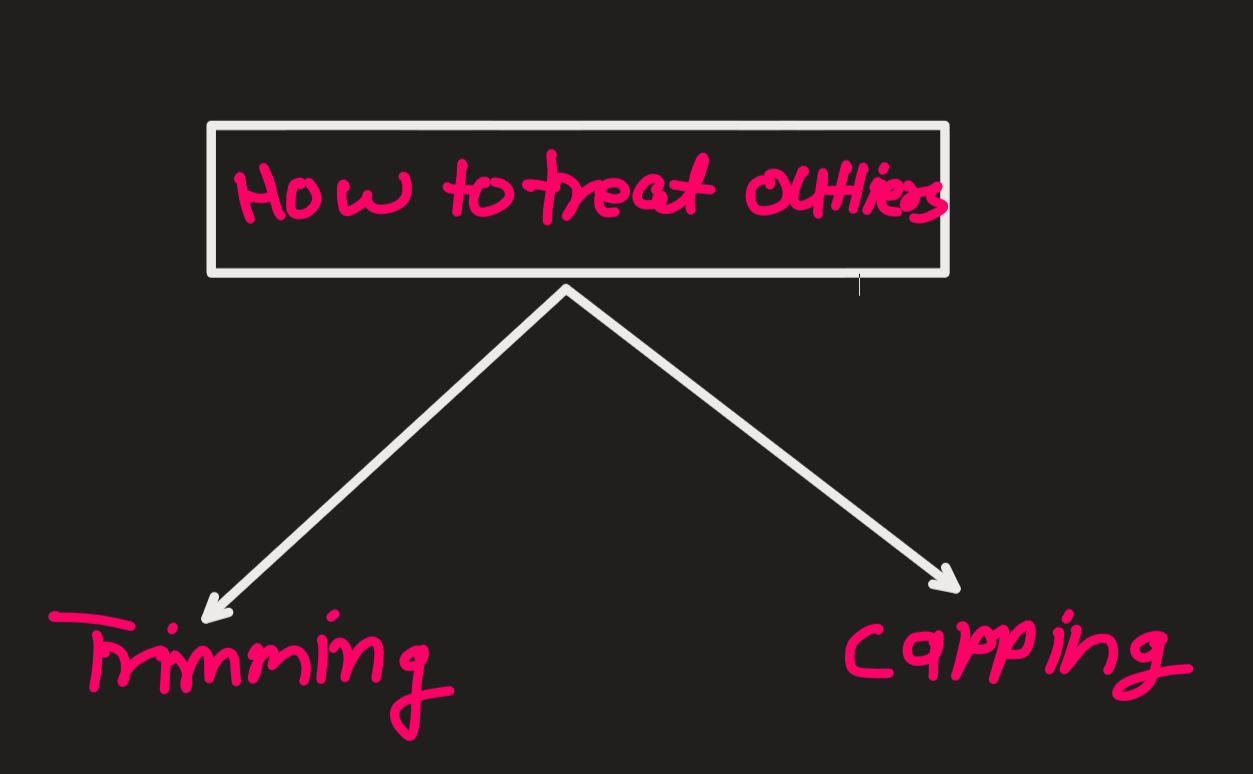

# **A. Trimming Method (Removing Outliers)**
- Trimming means deleting the outlier values from the dataset.
- We remove rows where the value is less than the lower limit or greater than the upper limit. This helps keep only the "normal" range of data.

**When should we use Trimming?**
- When the dataset is large
- When the outliers are clearly wrong (like Age=300 or Fare=10000)

**How Trimming Works**
- We calculate the lower limit and upper limit using the IQR method.
- Then we keep only the rows between those limits.
- Rows outside those limits are removed.

**Step by Step Code Example**
- Let's use the Age column from the Titanic dataset.

**Step 1: Calculate the IQR and Limits**

In [ ]:
# Calculate Q1, Q3 and IQR
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -6.6875
Upper Limit: 64.8125


**Let’s understand what that means**

- The lowest allowed value for Age = -6.6875
- The highest allowed value for Age = 64.8125

Now, of course, age can’t be negative, so practically, that lower value just means there are no outliers on the lower side.
But any Age greater than 64.81 will be treated as an outlier.

**Step 2: Remove the outlier rows**

In [ ]:
# Keep only rows within the limits
df_trimmed = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

print("Original Shape:", df.shape)
print("After Trimming:", df_trimmed.shape)

Original Shape: (891, 12)
After Trimming: (703, 12)


- It keeps all rows where Age is between -6.68 and 64.81.
- It removes any passenger whose Age is above 64.81 (like 70, 80, etc.)

That’s how Trimming works - using those two limits.

**Step 3: Visualize before and after trimming**

/tmp/ipython-input-3706394791.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['Age'].dropna(), df_trimmed['Age'].dropna()],


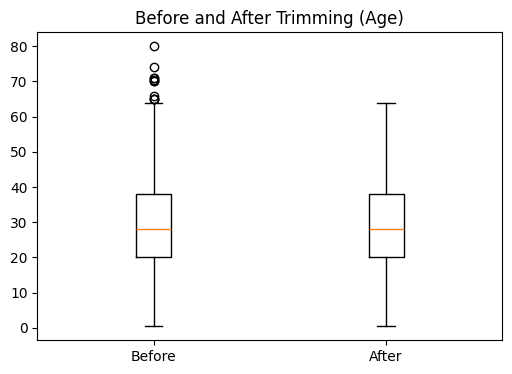

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot([df['Age'].dropna(), df_trimmed['Age'].dropna()],
            labels=['Before', 'After'])
plt.title("Before and After Trimming (Age)")
plt.show()

# **B. Capping Method (Replacing Outliers)**

Capping means we don't delete the outluier rows, we keep them but we replace the extreme values with the limit values (lower or upper).

it's like saying:
- Don't remove the person, just correct their value a little bit.

**Why Do We Use Capping?**

Sometimes, we can’t afford to lose data  especially if our dataset is small. In that case, instead of removing rows, we just push the outlier values back into the acceptable range.

**How It Works**

We already have the two limits from the IQR method:
- Lower Limit = Q1 - 1.5 x IQR
- Upper Limit = Q3 + 1.5 x IQR

Now we do this:
- If value < Lower Limit → replace with Lower Limit
- If value > Upper Limit → replace with Upper Limit

**Step by Step Code Example**

Let's again take the Age colummnn for demonstration

**Step 1: Calculate the limits (same as before)**

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -6.6875
Upper Limit: 64.8125


**Step 2: Apply Capping (replace outliers with limits)**

In [ ]:
import numpy as np

df_capped = df.copy()

df_capped['Age'] = np.where(
    df_capped['Age'] > upper_limit, upper_limit,
    np.where(df_capped['Age'] < lower_limit, lower_limit, df_capped['Age'])
)

/tmp/ipython-input-2103678295.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['Age'].dropna(), df_capped['Age'].dropna()],


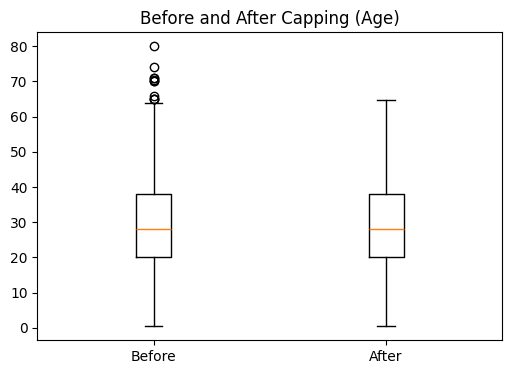

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot([df['Age'].dropna(), df_capped['Age'].dropna()],
            labels=['Before', 'After'])
plt.title("Before and After Capping (Age)")
plt.show()

# **2. Encoding (Converting Categorical Data into Numbers)**

In a dataset, some columns contain text values instead of numbers. For example:
| Gender | City   | Class |
| ------ | ------ | ----- |
| Male   | Delhi  | 1st   |
| Female | Mumbai | 2nd   |


- Machine learning models cannot understand text, they only understand numbers.
- So, we convert these text categories into numbers - this process is called Encoding.

**Why Do We Need Encoding?**

let's say we have a dataset like this
| Name | Gender | Age | Fare |
| ---- | ------ | --- | ---- |
| John | Male   | 22  | 72   |
| Mary | Female | 30  | 50   |


If we give this to a machine learning model, it won’t understand what “Male” or “Female” means.

So, we must encode these words into numbers, such as:
- Male → 1
- Female → 0

Now the model can use this information mathematically.

**Types of Encoding**

1. Label Encoding — turn each category into a single number (e.g., Male → 1, Female → 0).
2. One-Hot Encoding — create separate 0/1 columns for each category (e.g., City: Delhi/Mumbai/Chennai).
3. Ordinal Encoding — assign ordered numbers when categories have a natural order (e.g., Small < Medium < Large).

# **A. Label Encoding**

Label Encoding converts text categories into integers so models can use them.

**Why we use it**
- ML models understand numbers, not text.
- Fast and simple for binary categories (two values).

**When to use**

- Binary columns (e.g., Gender: Female/Male).
- Target labels like Yes/No → 1/0 (if your target is textual).

In [ ]:
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create object of LabelEncoder
le = LabelEncoder()

# Apply it to the 'sex' column
df['Gender'] = le.fit_transform(df['Gender'])

# Check the transformed column
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df['Gender'].value_counts()

,count
Gender,
1,577
0,314


'female' = 0 and 'male' = 1

# **B. One-Hot Encoding**

Sometimes, a column has more than two categories, for example, the Embarked column in the Titanic dataset:
| Passenger | Embarked |
| --------- | -------- |
| 1         | S        |
| 2         | C        |
| 3         | Q        |


Here we have 3 categories: S, C, and Q.

- If we use Label Encoding (S=0, C=1, Q=2), the model might think Q > C > S,
which creates a false order that doesn’t actually exist!
- So instead of numbers, we create separate columns for each category.
Each column will have only 0 or 1 values.

**Why We Use One-Hot Encoding**

- Machine learning models need numbers not text.
- But we also want to make sure no fake ranking happens.
- So we use 0 and 1 to show the presence of each category.

**When to Use One-Hot Encoding**

**When:**

- The column has 3 or more unique categories
- The categories don’t have order

**Avoid if:**

- Column has too many categories (like hundreds of cities) — it can create too many new columns.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

**Apply One-Hot Encoding**

- Using pandas get_dummies()

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Embarked'])
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,False,True


In [ ]:
df_encoded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

**Optional - drop one dummy column**

When using ML models, we sometimes drop one column to avoid dummy variable trap (when one column can be predicted from others).

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,True


# **C. Ordinal Encoding**

- Ordinal Encoding is used when your data has categories with a natural order or ranking.
- Unlike One-Hot or Label Encoding, here the order matters.

Example:

| Size   | Meaning     |
| ------ | ----------- |
| Small  | 1 (lowest)  |
| Medium | 2           |
| Large  | 3 (highest) |

Here “Large” is bigger than “Medium,” and “Medium” is bigger than “Small”.
So we can safely assign numbers based on that order.

**Why We Use Ordinal Encoding**
- Because some categorical values represent levels or rankings,and that order should be preserved when converted into numbers.
- If we used One-Hot Encoding, we’d lose that order information.

**When to Use Ordinal Encoding**
Use when categories have order
Examples:

- Education: Primary < Secondary < Graduate < Postgraduate
- Rating: Poor < Average < Good < Excellent
- Size: Small < Medium < Large
- Ticket Class: 3rd < 2nd < 1st

**Step by Step Code Example**

In [ ]:
data = {
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small', 'Large']
}
df = pd.DataFrame(data)
df

,Size
0,Small
1,Medium
2,Large
3,Medium
4,Small
5,Large


**Apply Ordinal Encoding**

We’ll use OrdinalEncoder from scikit-learn.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
df['Size_Encoded'] = encoder.fit_transform(df[['Size']])

df

,Size,Size_Encoded
0,Small,0.0
1,Medium,1.0
2,Large,2.0
3,Medium,1.0
4,Small,0.0
5,Large,2.0


**Optional - Start encoding from 1**

In [ ]:
df['Size_Encoded'] = df['Size_Encoded'] + 1
df

,Size,Size_Encoded
0,Small,1.0
1,Medium,2.0
2,Large,3.0
3,Medium,2.0
4,Small,1.0
5,Large,3.0


# **3. Feature Scaling (Standardization & Normalization)**

This comes right after Encoding, because now that every column is numeric, we can finally bring all numbers onto a common scale

**Why Scaling is Needed**
After encoding, some columns might have values like:

- Age = 25, 50, 75
- Fare = 7, 512, 100

These values are on different scales.
Machine learning models can get confused and give more importance to bigger numbers.

That’s why we do Feature Scaling - to make all numeric data comparable.

# **A. Standardization**

Standardization is a way to scale numerical data so that all features follow a similar scale. After standardization, each column will have:

- Mean = 0
- Standard Deviation = 1

**How It Works**

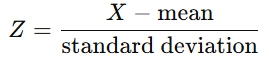

Where,
- X → original value
- mean → average of the column
- standard deviation → how spread out the values are
- Z → standardized value

After scaling:

- Most values lie roughly between –3 and +3
- The column mean becomes 0

**When To Use**

| Use Standardization When…                               | Examples                    |
| ------------------------------------------------------- | --------------------------- |
| Data looks normally distributed                         | Age, Height, Weight         |
| You plan to use distance-based or gradient-based models | KNN, SVM, Linear Regression |


**Step by Step Code Example**

**Apply Standardization**
- We’ll use StandardScaler from sklearn.preprocessing.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform numeric columns
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [ ]:
df[['Age','Fare']].describe()

,Age,Fare
count,7.140000e+02,8.910000e+02
mean,2.388379e-16,3.987333e-18
std,1.000701e+00,1.000562e+00
min,-2.016979e+00,-6.484217e-01
25%,-6.595416e-01,-4.891482e-01
50%,-1.170488e-01,-3.573909e-01
75%,5.718310e-01,-2.424635e-02
max,3.465126e+00,9.667167e+00


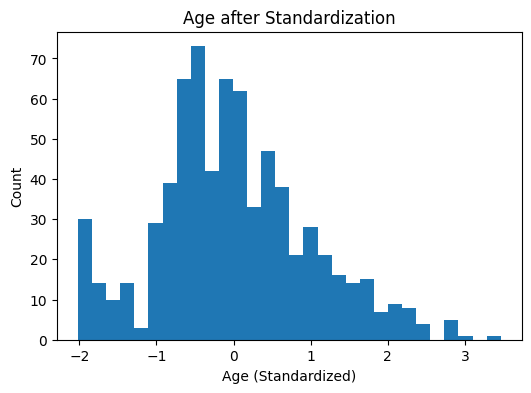

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=30)
plt.title('Age after Standardization')
plt.xlabel('Age (Standardized)')
plt.ylabel('Count')
plt.show()

# **B. Normalization**

Normalization is another method of scaling numeric data, but this time, instead of making mean = 0 and std = 1,
we bring all values between 0 and 1.

**How It Works**

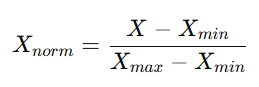

This ensures:

- The smallest value becomes 0
- The largest value becomes 1
- Everything else lies in between

**When To Use Normalization**

Use when:

- You want all data between 0 and 1
- You’re using distance-based algorithms (KNN, SVM, Neural Networks)
- Your data doesn’t follow a normal distribution

Avoid when:

- Data already centered around mean = 0
- You’re using algorithms like Linear Regression (prefer Standardization there)

**Apply Normalization**

We’ll use MinMaxScaler from sklearn.preprocessing.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit and transform numeric columns
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [ ]:
df[['Age','Fare']].describe()

,Age,Fare
count,714.000000,891.000000
mean,0.367921,0.062858
std,0.182540,0.096995
min,0.000000,0.000000
25%,0.247612,0.015440
50%,0.346569,0.028213
75%,0.472229,0.060508
max,1.000000,1.000000


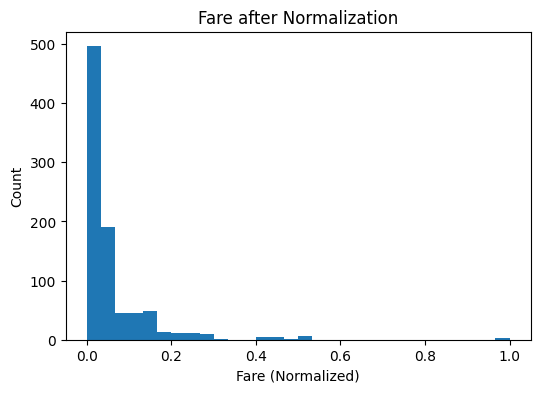

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Fare'], bins=30)
plt.title('Fare after Normalization')
plt.xlabel('Fare (Normalized)')
plt.ylabel('Count')
plt.show()

Example:

Before Normalization
| Passenger | Age | Fare  |
| --------- | --- | ----- |
| 1         | 22  | 7.25  |
| 2         | 38  | 71.28 |
| 3         | 26  | 8.05  |

After Normalization
| Passenger | Age  | Fare |
| --------- | ---- | ---- |
| 1         | 0.28 | 0.01 |
| 2         | 0.59 | 0.14 |
| 3         | 0.32 | 0.02 |


Difference Between Standardization & Normalization

| Feature      | Standardization           | Normalization               |
| ------------ | ------------------------- | --------------------------- |
| Formula      | (x - mean)/std            | (x - min)/(max - min)       |
| Output Range | Around -3 to +3           | 0 to 1                      |
| Keeps shape? | Yes                       | No (compresses data)        |
| When to use  | Normally distributed data | Skewed or varied-range data |
